In [33]:


from scipy.optimize import root_scalar, root
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from decimal import Decimal
from math import isclose
import sys

import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
cm = 1/2.54  
width = 12*cm 



In [34]:
class TickProperties():
    
    major_xtick_step = 5,
    minor_xtick_step = 1
    major_ytick_step = 5
    minor_ytick_step = 1
    STRIP_OF_ZEROS_X = False
    STRIP_OF_ZEROS_Y = False

    def __init__(self,\
    xtick_step_major = 5,\
    xtick_step_minor = 1,\
    ytick_step_major = 5,\
    ytick_step_minor = 1,\
    SZX = False,\
    SZY = False):
        self.major_xtick_step = xtick_step_major
        self.minor_xtick_step = xtick_step_minor
        self.major_ytick_step = ytick_step_major
        self.minor_ytick_step = ytick_step_minor
        self.STRIP_OF_ZEROS_X = SZX
        self.STRIP_OF_ZEROS_Y = SZY

class Format():
    numb_xticks = None
    numb_yticks = None
    custom_func_x = None
    custom_func_y = None
    x_scale = None
    y_scale = None
    x_precion = "{:.2f}"
    y_precion = "{:.2f}"
    def __init__(self,numb_xticks=None,numb_yticks=None,custom_funx=None,custom_funy=None,xscale=None,yscale=None,xprec="{:.2f}",yprec="{:.2f}"):
        self.numb_xticks =numb_xticks
        self.numb_yticks = numb_yticks
        self.custom_func_x = custom_funx
        self.custom_func_y = custom_funy
        self.x_precion=xprec
        self.y_precion = yprec
        self.x_scale = xscale
        self.y_scale = yscale
    def formatx0(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            # print(x,pos,self.numb_xticks)
            index = int((pos-1)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print(self.x_precion.format(self.x_scale[index]))
            return self.x_precion.format(self.x_scale[index])
        except:
            return self.x_precion.format(self.x_scale[-1])
    def formatx1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            # print(pos)
            index = int((pos)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print()
            return self.x_precion.format(self.x_scale[index])
        except:
            return self.x_precion.format(self.x_scale[-1])
    
    def formaty1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))

            index = int((pos-1)*self.y_scale.shape[0]//self.numb_yticks)
            # print(index)
            # print()
            return self.y_precion.format(self.y_scale[index])
        except:
            return self.y_precion.format(self.y_scale[-1])
        
    def formaty(self,x,pos):
        try:
            return self.y_precion.format(self.y_scale[int(x)])
        except:
            return ""

class Setup_Fig():
    DEFAULT_HEAT_EXTEND = (-0.5,39.5,29.5,-0.5)
    xlim = None
    ylim = None
    tickprop = TickProperties()
    formatter = Format()
    cm = 1/2.54 
    fig_width = 12*cm
    fig_height = 4.8/6.4*12*cm
    name_of_plot = None
    def __init__(self,name_of_plot = "sign_of_ev1.pdf",xlim=None,ylim=None,tickp=TickProperties(),formater=Format()):
        self.xlim=xlim
        self.ylim = ylim   
        self.tickprop =tickp       
        self.formatter = formater
        self.name_of_plot = name_of_plot

    
    plt.rcParams["lines.markersize"]=0.7
    plt.rcParams["axes.unicode_minus"]=True
    plt.rcParams["font.size"]=10
    plt.rcParams["text.usetex"]=True
    plt.rcParams["font.serif"]="Computer Modern Serif"
# ax.scatter(A,root,color='0')
    



    def return_fig(self,shape=(1,1),dots_per_inch=400,xax_share=False,yax_share=False,joined=False,set_ticks=True,heightratio=None):
        if heightratio:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=xax_share,sharey=yax_share,height_ratios=heightratio)
        else:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=xax_share,sharey=yax_share)
        trash, xw, yw, trash=self.DEFAULT_HEAT_EXTEND# im.get_extent()
        self.formatter.numb_xticks = xw//self.tickprop.major_xtick_step
        self.formatter.numb_yticks = yw//self.tickprop.major_ytick_step
        
        for i in range(shape[0]):
            for j in range(shape[1]):
                pos= 'outer_left'
                if shape[0]==1:
                    if shape[1]==1:
                        current_ax = ax
                    else:
                        current_ax = ax[j]
                else:
                    if shape[1]==1:
                        current_ax = ax[i]
                    else:
                        current_ax = ax[i,j]
                        if j==0:
                           pos= 'outer_left'
                        elif j<shape[1]-1:
                            pos = 'middle'
                        elif j==shape[1]-1:
                            pos = 'outer_right'
                        


        # axlimits have to be adapted
                try:
                    current_ax.set_xlim(*self.xlim)
                except:
                    pass
                try:
                    current_ax.set_ylim(*self.ylim)
                except:
                    pass    
            
                if set_ticks:
                    if self.tickprop.STRIP_OF_ZEROS_X:
                        current_ax.xaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formatx0))
                    current_ax.yaxis.set_major_locator(ticker.MultipleLocator(self.tickprop.major_ytick_step))
                    current_ax.yaxis.set_minor_locator(ticker.MultipleLocator(self.tickprop.minor_ytick_step))
                    current_ax.xaxis.set_major_locator(ticker.MultipleLocator(self.tickprop.major_xtick_step))
                    current_ax.xaxis.set_minor_locator(ticker.MultipleLocator(self.tickprop.minor_xtick_step))

                    if self.tickprop.STRIP_OF_ZEROS_Y:
                        current_ax.yaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formaty1))  

                if joined:
                    if i<shape[0]-1:
                        current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=False)
                    else:
                        current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
                        
                    if pos=='outer_left':
                        current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)
                    elif pos=='middle':
                        current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=False)
                    elif pos=='outer_right':
                        current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelright=True)
                        # current_ax.set_xlabel(r'$\Gamma \tilde{A}$')
                        # current_ax.set_ylabel(r'$\tilde{y}$',rotation=0)
                else:
                    current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
                    
                    current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)   


                current_ax.tick_params(axis='both',which='major',length=4.5)
                plt.setp(current_ax.yaxis.get_majorticklabels(),va='center')
        
        return fig, ax


In [8]:

	
u = [3,4,5]
n= [16,21,27]
dn = [16/3,5,6]
d, dd = (0.35/225/1000,0.35/225/36/1000)
n, dn = np.mean(dn), np.std(dn)
lam, dellam = d/n, np.sqrt((d/n**2*dn)**2+(dd/n)**2)
lam, dellam*2, dd*2

(np.float64(2.857142857142857e-07),
 np.float64(4.643189870577521e-08),
 8.641975308641975e-08)

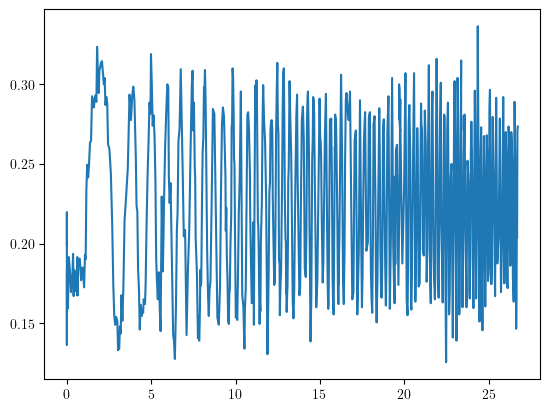

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
df =pd.read_csv("MS Messung1.csv")
data1 = df.to_numpy()
plt.figure()
data1[:,2] = data1[:,2]/data1[-225,2]*90
start = 0
end = 700
plt.plot(data1[start:end,2],data1[start:end,1])
# plt.plot(data1[:end,2],np.mean(data1[:end,1])*np.ones(end))
# plt.plot(data1[:end,2],0.243*np.ones(end))
plt.show()

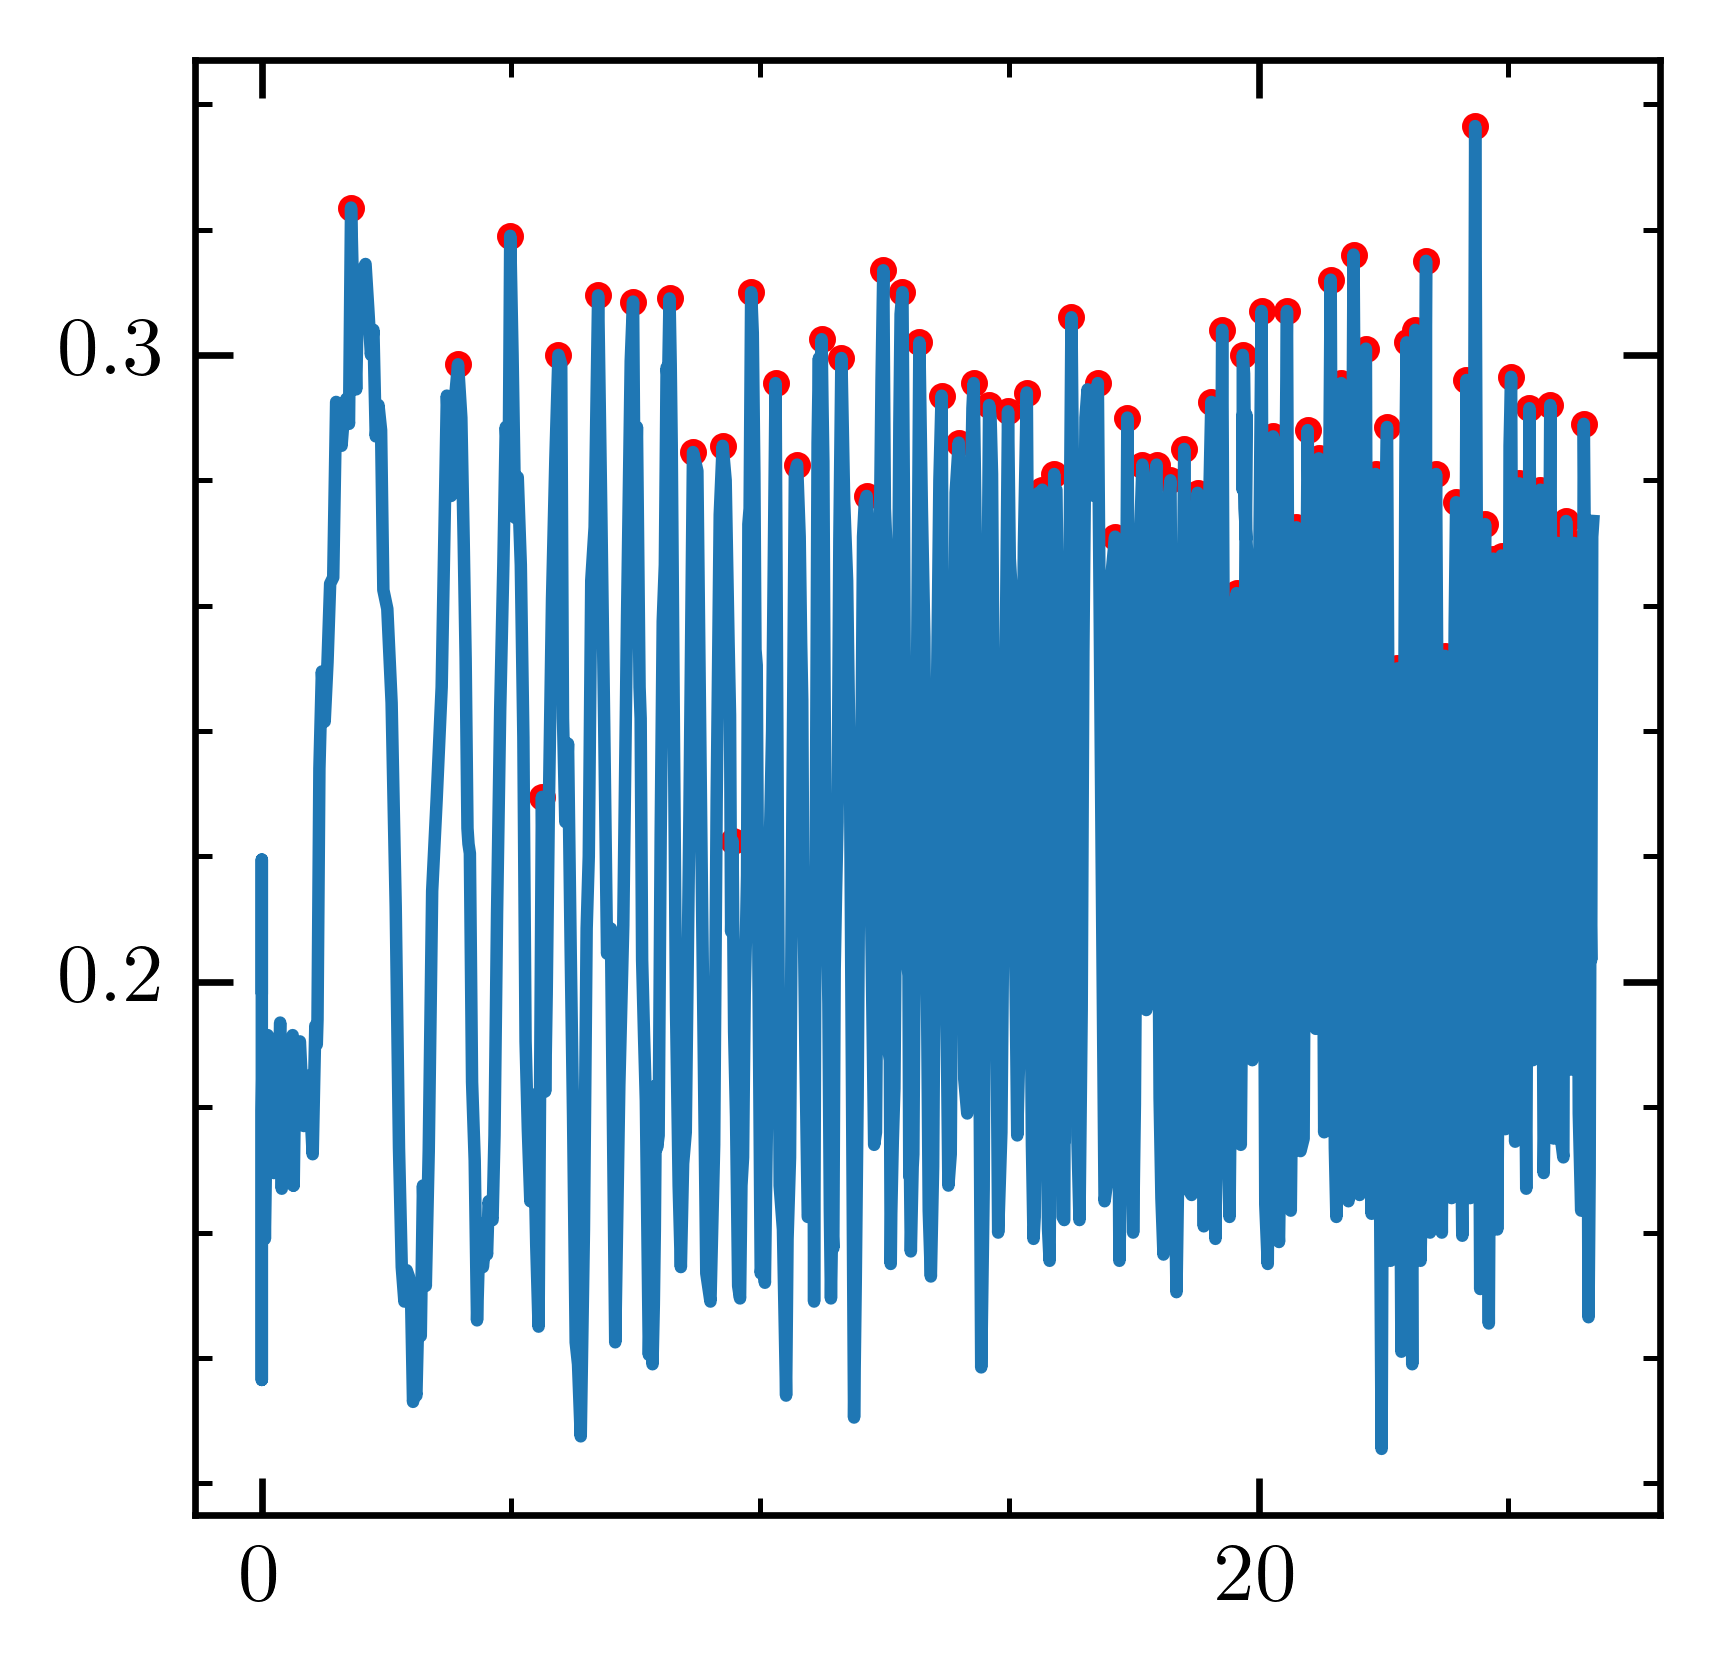

In [105]:

start =0
m = np.mean(data1[:end,1])
indices = []

for i in range(start,end):
    if (data1[i-1,1]<=m and data1[i,1]>m) or (data1[i-1,1]>=m and data1[i,1]<m):
        indices.append(i)
maxima_pos = []
maxima = []
for j in range(0,len(indices)-1,2):
    maxi = np.max(data1[indices[j]:indices[j+1],1])
    pos = data1[list(data1[indices[j]:indices[j+1],1]).index(maxi)+indices[j],2]
    maxima_pos.append(pos)
    maxima.append(maxi)
numb = np.arange(1,len(maxima_pos)+1)

# plots = [stab_xsol,stab_ysol,stab_zsol]
tickp = TickProperties(SZX=False,SZY=False,\
                       xtick_step_major=20,\
                        xtick_step_minor=5,\
                            ytick_step_major=0.1,\
                                ytick_step_minor=0.02)
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',tickp=tickp)
plot_dim = (-0.5, 60.5, 60.5, -0.5)
setup.fig_width= 8*cm
setup.fig_height=8*cm #29.1*cm


fig, ax = setup.return_fig(shape=(1,1),dots_per_inch=600)

ax.plot(data1[start:end,2],data1[start:end,1])
ax.scatter(maxima_pos,maxima,s=5,color='red')
plt.show()
# plt.scatter(data1[indices,2],data1[indices,1],s=5,color='green')
# plt.plot(data1[start:end,2],np.ones(end-start)*m)
# plt.show()
# plt.figure()
# plt.scatter(maxima_pos,numb,s=1)
# plt.show()



In [112]:
numb = np.array(numb)
maxima_pos = np.array(maxima_pos)

def fit_glas(alpha,n,b,c,d):
    lam = 550
    cosbeta = np.sqrt(n**2-np.sin(alpha-d)**2)
    return 2*b*(cosbeta-(1)*np.cos(alpha-d))-c
def glas_wrap(p):
    return np.sum((numb-fit_glas(maxima_pos/180*np.pi,*p))**2)/end
from scipy.optimize import minimize, curve_fit
opt = {'maxiter':10**5}
min_res = minimize(glas_wrap,[1.4,200,900,0],bounds=[(1,2),(0,10**8),(-np.inf,np.inf),(-np.pi/2,np.pi/2),])#,method='Nelder-Mead',options=opt)
fit_res = curve_fit(fit_glas,maxima_pos/180*np.pi,ydata=numb,p0=[1.6,200,900,0],maxfev=10000,xtol=0.001)#,bounds=np.array([(1,2),(0,10**8),(-np.inf,np.inf),(-np.pi/2,np.pi/2)]).T)

fit_res, np.sqrt(np.diag(fit_res[1]))

((array([ 1.64190542e+00,  8.40767712e+02,  1.07828366e+03, -3.75953996e-03]),
  array([[ 3.27159936e-01, -2.31917168e+02,  2.52137522e+02,
           5.41633623e-03],
         [-2.31917168e+02,  1.64597885e+05, -1.78487931e+05,
          -3.77656217e+00],
         [ 2.52137522e+02, -1.78487931e+05,  1.94630308e+05,
           4.25345264e+00],
         [ 5.41633623e-03, -3.77656217e+00,  4.25345264e+00,
           1.10494540e-04]])),
 array([5.71978964e-01, 4.05706648e+02, 4.41169251e+02, 1.05116383e-02]))

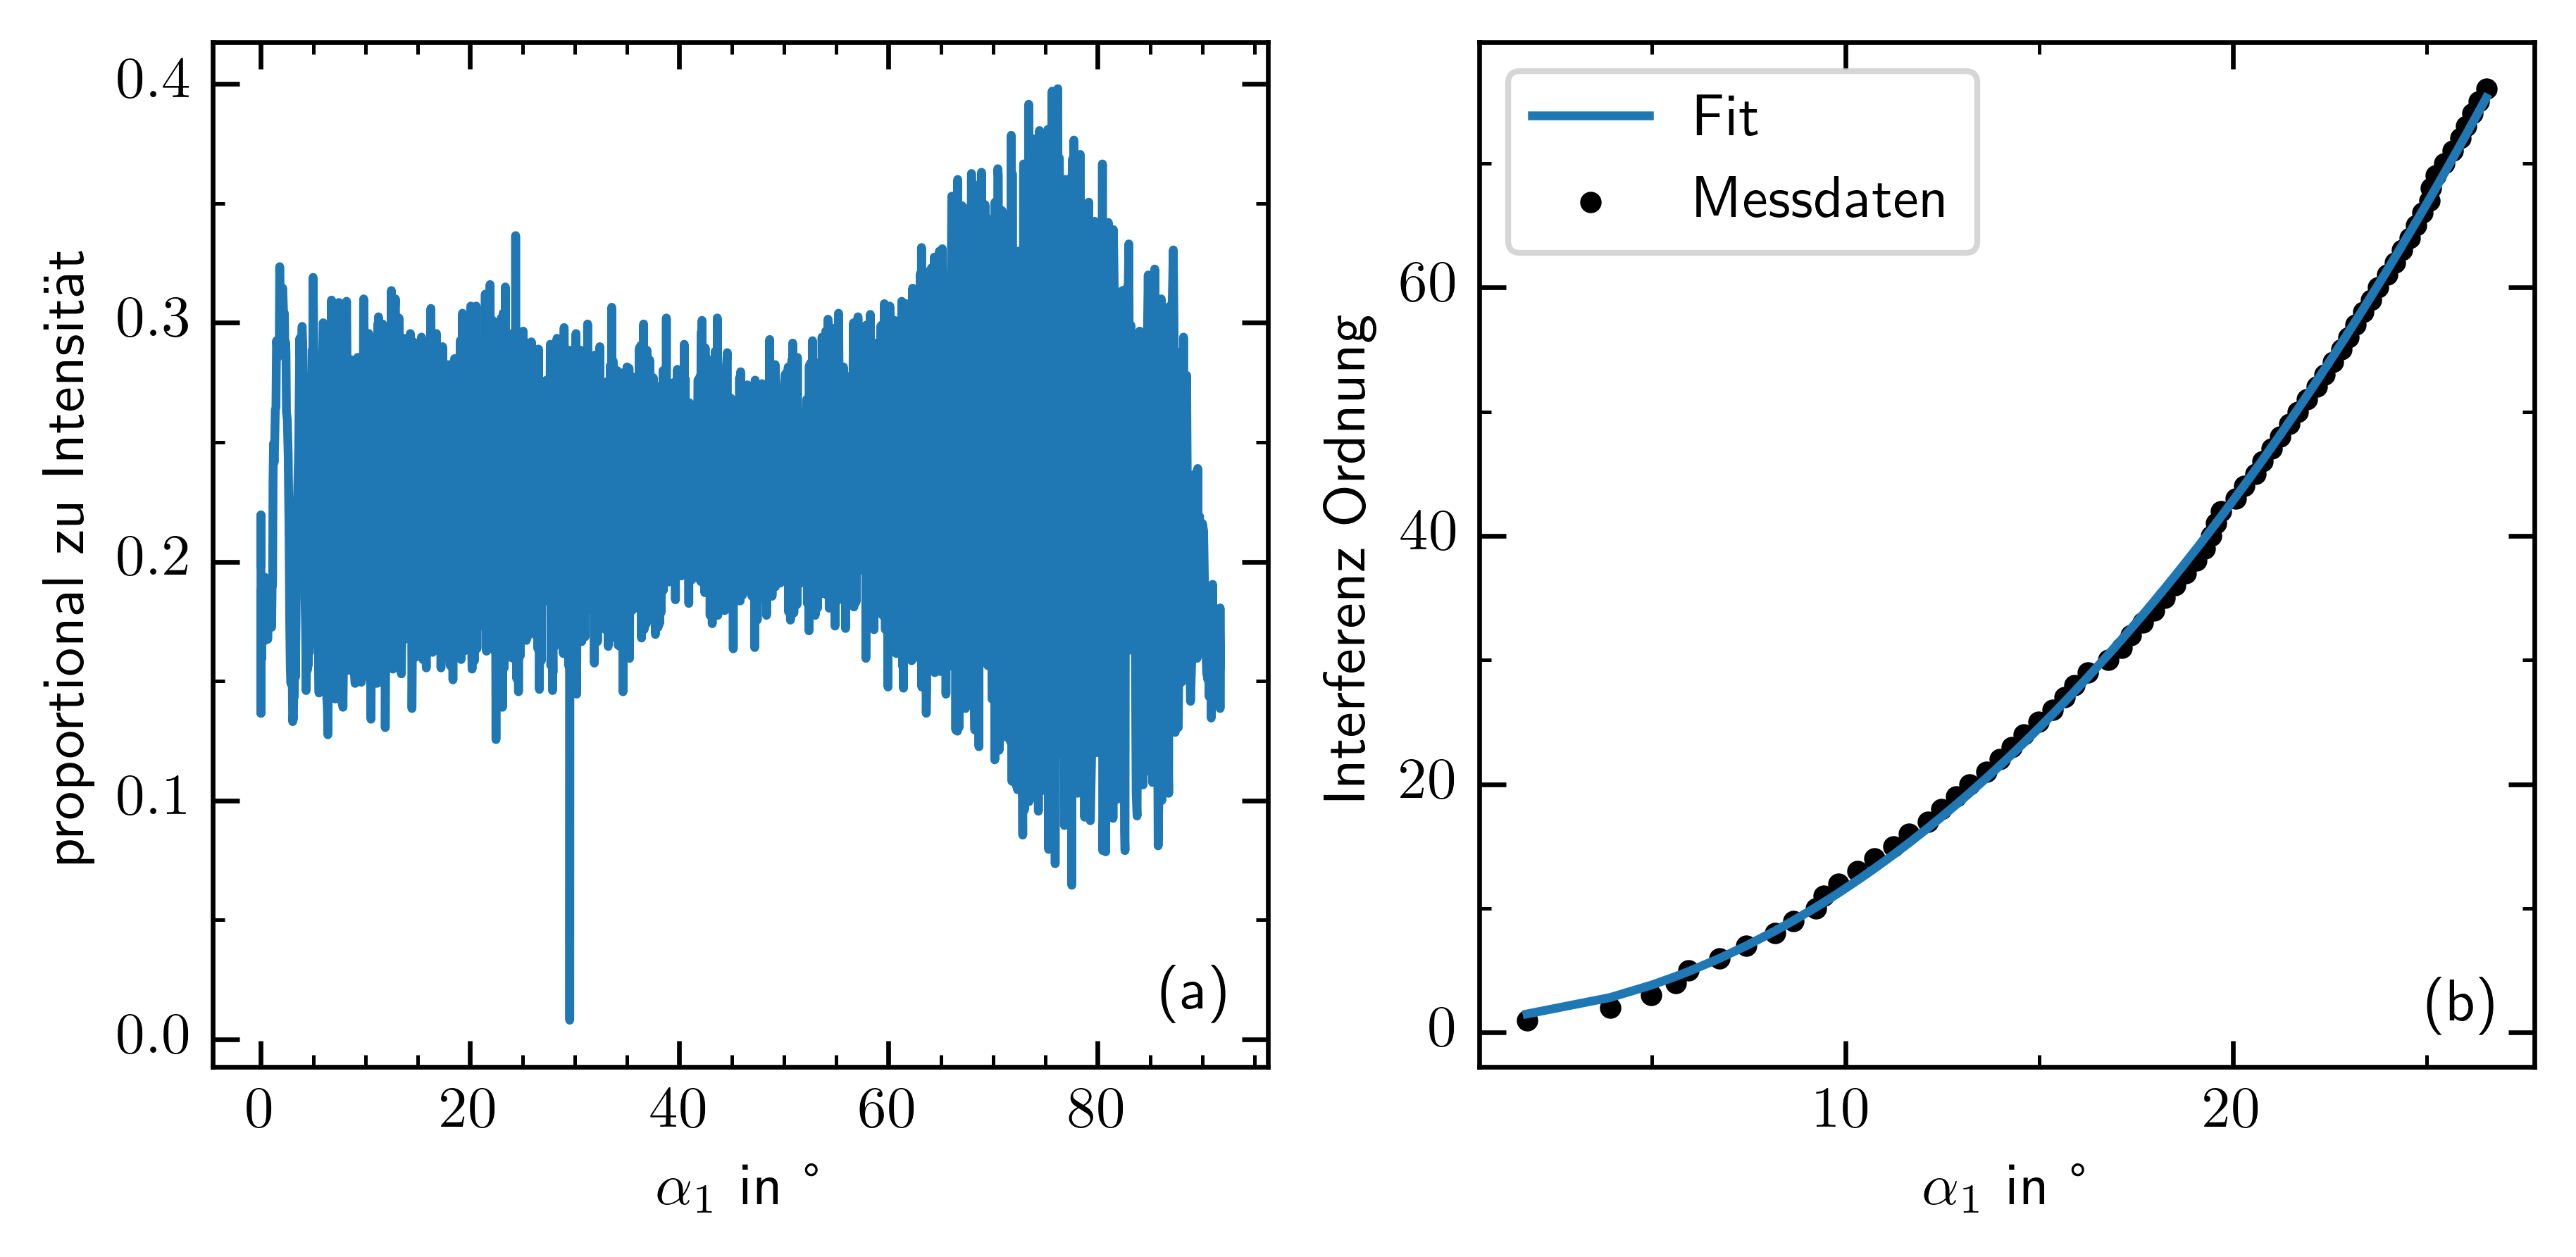

In [ ]:
tickp = TickProperties(SZX=False,SZY=False,\
                       xtick_step_major=10,\
                        xtick_step_minor=5,\
                            ytick_step_major=20,\
                                ytick_step_minor=10)
setup = Setup_Fig(name_of_plot='glas_ausw.pdf',tickp=tickp)
plot_dim = (-0.5, 60.5, 60.5, -0.5)
setup.fig_width= 18*cm
setup.fig_height=8*cm #29.1*cm
fig, ax = setup.return_fig(shape=(1,2),dots_per_inch=600)
ax[0].plot(data1[:,2],data1[:,1])
ax[0].set_xlabel(r"$\alpha_1$ in °")
ax[0].set_ylabel(r"proportional zu Intensität")
ax[0].yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax[0].yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
ax[0].xaxis.set_major_locator(ticker.MultipleLocator(20))
ax[0].xaxis.set_minor_locator(ticker.MultipleLocator(5))

ax[1].plot(maxima_pos,fit_glas(maxima_pos/180*np.pi,*fit_res[0]))
ax[1].scatter(maxima_pos,numb,s=7,color='0')
ax[1].set_xlabel(r"$\alpha_1$ in °")
ax[1].set_ylabel(r"Interferenz Ordnung")
ax[1].legend([r"Fit",r"Messdaten"])
ax[0].text(86,0.013,'(a)')
ax[1].text(25,1,'(b)')
# plt.savefig("/home/christian/Documents/Praktikum/MS_Christian_Matteo/pictures/"+setup.name_of_plot)
plt.show()